--- 1. Analyse Exploratoire des Données ---
Contents of the outer zip file: ['creditcard.csv.zip']
Taille du dataset: (284807, 31)
Valeurs manquantes: 0

Distribution des classes:
Class
0    284315
1       492
Name: count, dtype: int64


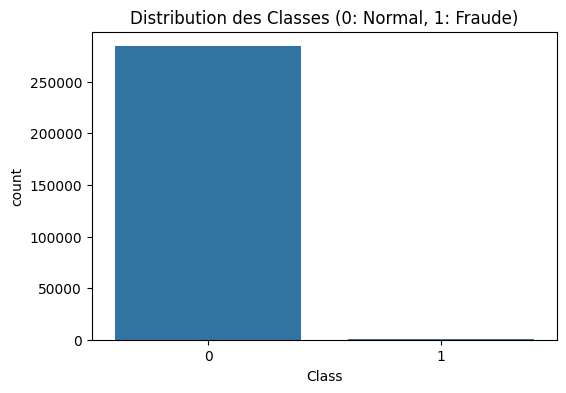

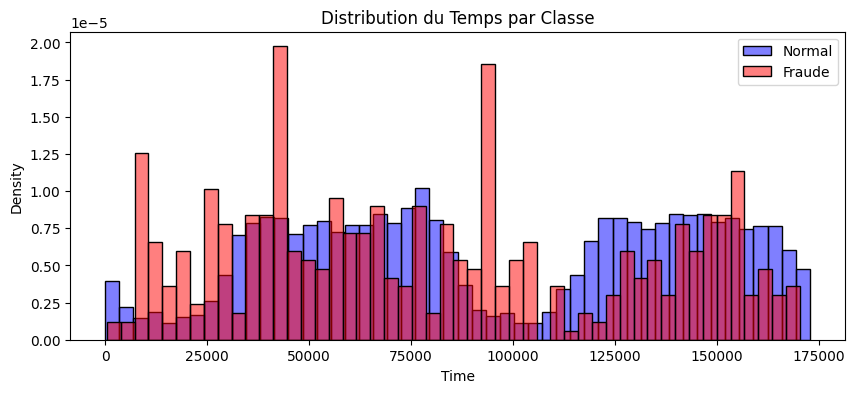

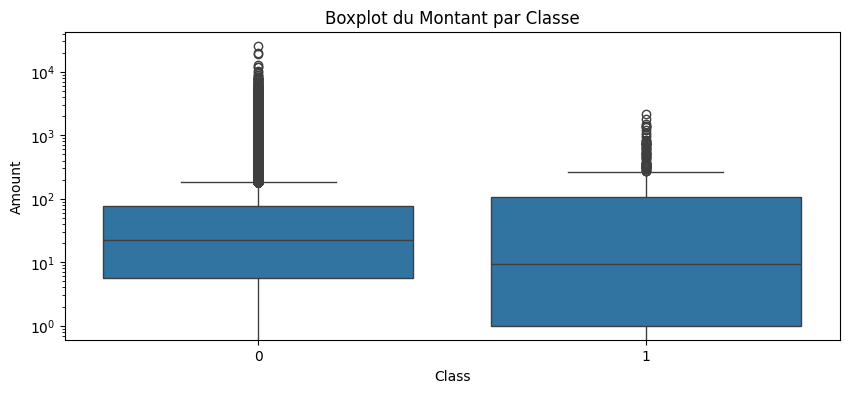

Calcul de la matrice de corrélation...


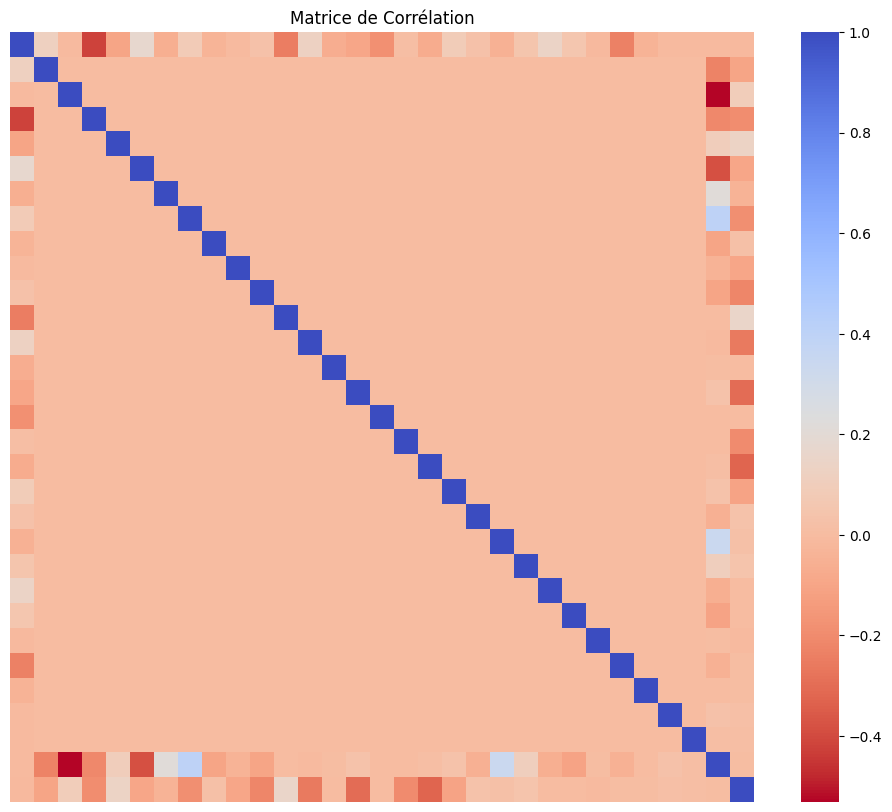


--- 2. Préparation des données (RobustScaler) ---

Séparation des données (Train/Test)...
Format Entraînement: (227845, 30), Format Test: (56962, 30)

--- 3. Gestion du déséquilibre (SMOTE) ---
Format Entraînement après SMOTE: (454902, 30)

--- 4. Entraînement et Évaluation des Modèles ---

--> Apprentissage du modèle LogisticRegression...
Résultats LogisticRegression -> Précision: 0.0591 | Rappel: 0.9184 | F1: 0.1110 | AUC: 0.9712

--> Apprentissage du modèle RandomForest...
Résultats RandomForest -> Précision: 0.4028 | Rappel: 0.8673 | F1: 0.5502 | AUC: 0.9834


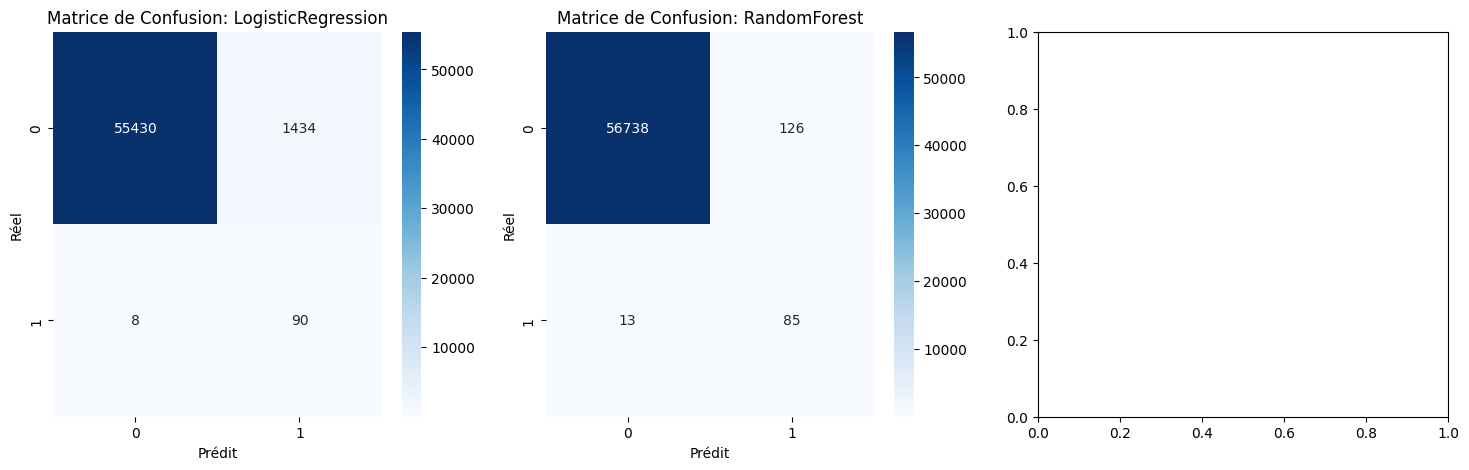

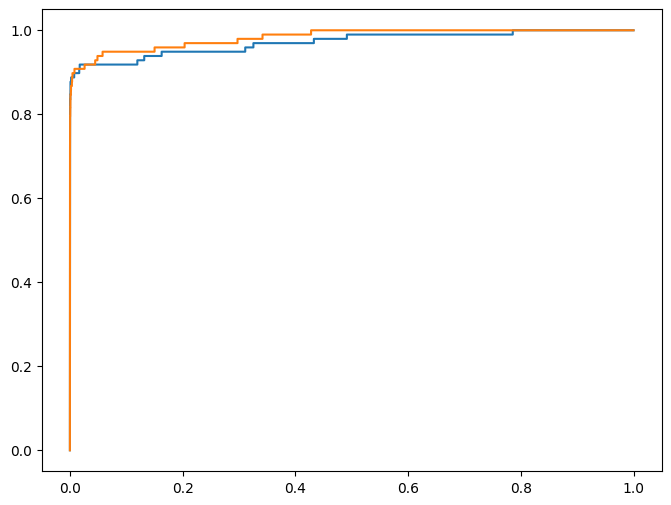

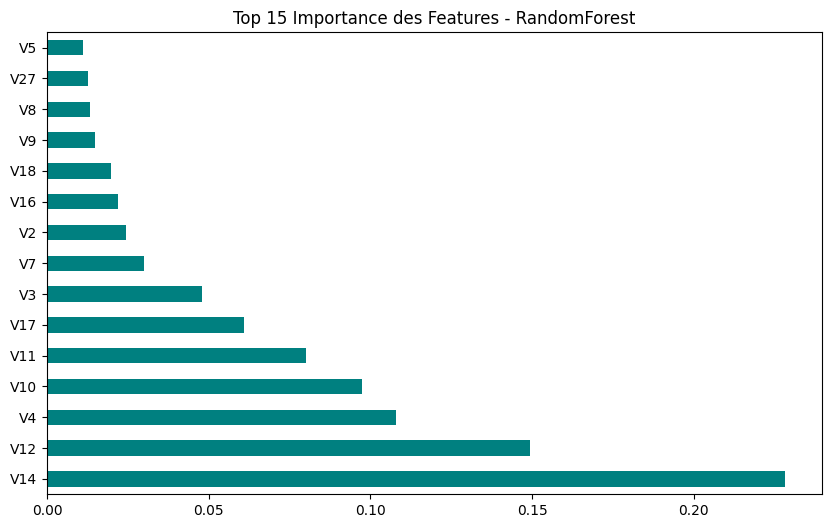


--> Apprentissage du modèle XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:43:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Résultats XGBoost -> Précision: 0.7179 | Rappel: 0.8571 | F1: 0.7814 | AUC: 0.9779


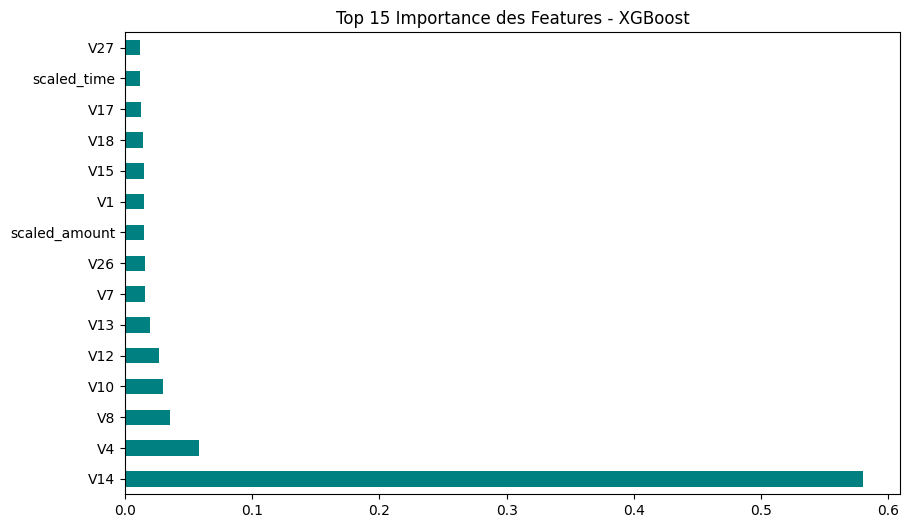


             RÉSUMÉ DES RÉSULTATS            
            Modèle  Précision  Precision_Score   Rappel  F1-Score      AUC
LogisticRegression   0.974685         0.059055 0.918367  0.110974 0.971219
      RandomForest   0.997560         0.402844 0.867347  0.550162 0.983361
           XGBoost   0.999175         0.717949 0.857143  0.781395 0.977898


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile # Import the zipfile module
import tempfile # Import tempfile for temporary file handling

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, roc_curve, classification_report

# Chemin des données : on suppose que le fichier a été importé à la racine de Colab
data_path = "/content/creditcard.csv (2).zip"

# ==========================================================
# 1. ANALYSE EXPLORATOIRE DES DONNÉES (EDA)
# ==========================================================
print("--- 1. Analyse Exploratoire des Données ---")

# Explicitly handle the zip file, assuming it contains another zip file
with zipfile.ZipFile(data_path, 'r') as z_outer: # Open the outer zip file
    # List contents of the outer zip file
    inner_files = z_outer.namelist()
    print("Contents of the outer zip file:", inner_files)

    # Assuming there's only one inner file and it's the actual CSV (possibly zipped again)
    if not inner_files:
        raise ValueError("Outer zip file is empty.")

    inner_file_name = inner_files[0] # Get the name of the file inside the outer zip

    # Extract the content of the inner file to a temporary location
    with z_outer.open(inner_file_name, 'r') as f_inner_compressed_stream:
        # Create a temporary file to write the contents of the inner zip stream
        # This stream itself might be a compressed file (e.g., 'creditcard.csv.zip')
        with tempfile.NamedTemporaryFile(delete=True, suffix='.zip') as temp_extracted_file:
            temp_extracted_file.write(f_inner_compressed_stream.read())
            temp_extracted_file_path = temp_extracted_file.name

            # Now, read this temporary file with pandas.
            # We pass compression='zip' to pandas for this temporary file, as it's a zip itself.
            df = pd.read_csv(temp_extracted_file_path, compression='zip', encoding='latin-1', sep=',')

print("Taille du dataset:", df.shape)
print("Valeurs manquantes:", df.isnull().sum().max())
print("\nDistribution des classes:")
print(df['Class'].value_counts())

# Graphique 1 : Distribution des Classes
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df)
plt.title('Distribution des Classes (0: Normal, 1: Fraude)')
plt.show()

# Graphique 2 : Distribution du Temps par Classe
plt.figure(figsize=(10, 4))
sns.histplot(df['Time'][df['Class'] == 0], bins=50, color='blue', alpha=0.5, label='Normal', stat='density')
sns.histplot(df['Time'][df['Class'] == 1], bins=50, color='red', alpha=0.5, label='Fraude', stat='density')
plt.title('Distribution du Temps par Classe')
plt.legend()
plt.show()

# Graphique 3 : Boxplot du Montant par Classe & Outliers
plt.figure(figsize=(10, 4))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Boxplot du Montant par Classe')
plt.yscale('log') # Echelle logarithmique
plt.show()

# Graphique 4 : Matrice de Corrélation
print("Calcul de la matrice de corrélation...")
plt.figure(figsize=(12, 10))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm_r', xticklabels=False, yticklabels=False)
plt.title('Matrice de Corrélation')
plt.show()

# ==========================================================
# 2. PRÉPARATION DES DONNÉES
# ==========================================================
print("\n--- 2. Préparation des données (RobustScaler) ---")
# Utilisation de RobustScaler (résistant aux valeurs aberrantes)
rob_scaler = RobustScaler()

df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))

df.drop(['Time','Amount'], axis=1, inplace=True)

# Réorganisation des colonnes (scaled_amount et scaled_time au début)
scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']
df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)

X = df.drop('Class', axis=1)
y = df['Class']

print("\nSéparation des données (Train/Test)...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Format Entraînement: {X_train.shape}, Format Test: {X_test.shape}")

# ==========================================================
# 3. GESTION DU DÉSÉQUILIBRE DES CLASSES (SMOTE)
# ==========================================================
print("\n--- 3. Gestion du déséquilibre (SMOTE) ---")
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)
print(f"Format Entraînement après SMOTE: {X_train_sm.shape}")

# ==========================================================
# 4. ENTRAÎNEMENT & ÉVALUATION DES MODÈLES
# ==========================================================
print("\n--- 4. Entraînement et Évaluation des Modèles ---")
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)
}

results = []

fig_conf, axes_conf = plt.subplots(1, 3, figsize=(18, 5))
fig_roc, ax_roc = plt.subplots(figsize=(8, 6))

for idx, (name, model) in enumerate(models.items()):
    print(f"\n--> Apprentissage du modèle {name}...")
    model.fit(X_train_sm, y_train_sm)

    # Prédictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)

    # Métriques
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred) # Corrected: f1_score(y_test, y_pred) instead of f1_score(y_test, f1_score)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Modèle": name, "Précision": acc, "Precision_Score": prec, "Rappel": rec, "F1-Score": f1, "AUC": auc
    })
    print(f"Résultats {name} -> Précision: {prec:.4f} | Rappel: {rec:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}")

    # Matrices de Confusion
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_conf[idx])
    axes_conf[idx].set_title(f'Matrice de Confusion: {name}')
    axes_conf[idx].set_xlabel('Prédit')
    axes_conf[idx].set_ylabel('Réel')

    # Courbe ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax_roc.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

    # Feature Importances (si disponible pour le modèle)
    if hasattr(model, 'feature_importances_'):
        plt.figure(figsize=(10,6))
        feat_importances = pd.Series(model.feature_importances_, index=X.columns)
        feat_importances.nlargest(15).plot(kind='barh', color='teal')
        plt.title(f'Top 15 Importance des Features - {name}')
        plt.show()

# Affichage des matrices de confusion
fig_conf.tight_layout()
plt.show()

# Affichage des courbes ROC
ax_roc.plot([0, 1], [0, 1], 'k--')
ax_roc.set_xlabel('Taux de Faux Positif (FPR)')
ax_roc.set_ylabel('Taux de Vrai Positif (TPR)')
ax_roc.set_title('Comparaison des Courbes ROC')
ax_roc.legend(loc='lower right')
plt.show()

# Résumé final des performances
res_df = pd.DataFrame(results)
print("\n==============================================")
print("             RÉSUMÉ DES RÉSULTATS            ")
print("==============================================")
print(res_df.to_string(index=False))